## Configuration for work

In [1]:
# important imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# code to save the figures as high-res PNGs

IMAGES_PATH = Path() / "images"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [3]:
# setting the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Loading the data and checking its properties

**Dataset**
-[Student Performance and Learning Behavior Dataset](https://www.kaggle.com/datasets/adilshamim8/student-performance-and-learning-style/data)

In [4]:
student_data = pd.read_csv("student_performance.csv")  # loading csv file into dataframe

In [5]:
student_data.head()  #overview of top 5 rows

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


**Dataset properties**
- Study behaviors & engagement → StudyHours, Attendance, Extracurricular, AssignmentCompletion, OnlineCourses, Discussions
- Resources & environment → Resources, Internet, EduTech
- Motivation & psychology → Motivation, StressLevel
- Demographics → Gender, Age (18–30 years)
- Learning preference → LearningStyle
- Performance indicators → ExamScore, FinalGrade

1. **for gender**
    - 0 : Female
    - 1 : Male
2. **for learning style**
    - 0: Visual
    - 1: Auditory
    - 2: Reading/Writing
    - 3: Kinesthetic

In [6]:
student_data.shape

(14003, 16)

In [7]:
student_data.columns  #returns all the column

Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle',
       'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EduTech', 'StressLevel', 'FinalGrade'],
      dtype='object')

In [8]:
student_data.describe()  #genral insights of the data

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.905806,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.304363,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.695896,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,0.785383,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,1.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,2.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,2.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,2.000000,3.000000


In [9]:
student_data.info()  # idea abt what kind of data we have and null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [10]:
student_data.min()  # checking for minimum values

StudyHours               5
Attendance              60
Resources                0
Extracurricular          0
Motivation               0
Internet                 0
Gender                   0
Age                     18
LearningStyle            0
OnlineCourses            0
Discussions              0
AssignmentCompletion    50
ExamScore               40
EduTech                  0
StressLevel              0
FinalGrade               0
dtype: int64

In [11]:
student_data.max()  # for maximum values

StudyHours               44
Attendance              100
Resources                 2
Extracurricular           1
Motivation                2
Internet                  1
Gender                    1
Age                      29
LearningStyle             3
OnlineCourses            20
Discussions               1
AssignmentCompletion    100
ExamScore               100
EduTech                   1
StressLevel               2
FinalGrade                3
dtype: int64

In [12]:
student_data = student_data.astype("int8")  # As all values are small it's better to use int8 insted of int64 for better efficincy

In [13]:
student_data.info() # we can see the memory usage now as compared with previous

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int8 
 1   Attendance            14003 non-null  int8 
 2   Resources             14003 non-null  int8 
 3   Extracurricular       14003 non-null  int8 
 4   Motivation            14003 non-null  int8 
 5   Internet              14003 non-null  int8 
 6   Gender                14003 non-null  int8 
 7   Age                   14003 non-null  int8 
 8   LearningStyle         14003 non-null  int8 
 9   OnlineCourses         14003 non-null  int8 
 10  Discussions           14003 non-null  int8 
 11  AssignmentCompletion  14003 non-null  int8 
 12  ExamScore             14003 non-null  int8 
 13  EduTech               14003 non-null  int8 
 14  StressLevel           14003 non-null  int8 
 15  FinalGrade            14003 non-null  int8 
dtypes: i

In [14]:
student_data.isnull().sum()  # check if data have any null value

StudyHours              0
Attendance              0
Resources               0
Extracurricular         0
Motivation              0
Internet                0
Gender                  0
Age                     0
LearningStyle           0
OnlineCourses           0
Discussions             0
AssignmentCompletion    0
ExamScore               0
EduTech                 0
StressLevel             0
FinalGrade              0
dtype: int64

In [15]:
student_data.duplicated().sum()  # checking if data have duplicte values

np.int64(1534)

In [16]:
student_data = student_data.drop_duplicates() # dropping dupilates as it will create biasness when anylazing

In [17]:
student_data.shape # final shape of the data after droping the duplicates

(12469, 16)

In [18]:
student_data.duplicated().sum()  # duplicates = 0

np.int64(0)

## Feature Selection and Correlation Analysis

In [19]:
student_data.columns  # Columns names

Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle',
       'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EduTech', 'StressLevel', 'FinalGrade'],
      dtype='object')

In [20]:
cols_to_keep = ["StudyHours", "Attendance","AssignmentCompletion", 
                "OnlineCourses", "Discussions","Resources", "Internet", "EduTech","Motivation", "StressLevel","ExamScore"]  
# keeping columns for further 

In [21]:
student_data_clean = student_data[cols_to_keep].copy()  # new dataframe insted of dropping to have our raw dataframe untouched 

In [22]:
student_data_clean.head() # overview

,StudyHours,Attendance,AssignmentCompletion,OnlineCourses,Discussions,Resources,Internet,EduTech,Motivation,StressLevel,ExamScore
0,19,64,59,8,1,1,1,0,0,1,40
1,19,64,90,16,0,1,1,0,0,1,66
2,19,64,67,19,0,1,1,1,0,1,99
3,19,64,59,8,1,1,1,0,0,1,40
4,19,64,90,16,0,1,1,0,0,1,66


In [23]:
student_data_clean.shape #shape 

(12469, 11)

In [24]:
corr_columns = ["StudyHours", "Attendance", "Resources",
                "Motivation", "StressLevel","OnlineCourses", "AssignmentCompletion","ExamScore"]   # columns to calculate corr

In [25]:
corr = student_data_clean[corr_columns].corr(numeric_only=True) 

In [26]:
corr

,StudyHours,Attendance,Resources,Motivation,StressLevel,OnlineCourses,AssignmentCompletion,ExamScore
StudyHours,1.000000,0.028129,-0.003831,-0.004676,0.005621,-0.002186,0.008900,0.004201
Attendance,0.028129,1.000000,-0.012728,-0.004008,-0.017937,0.006515,-0.001892,-0.014156
Resources,-0.003831,-0.012728,1.000000,0.001126,-0.005875,0.003897,-0.002719,0.005119
Motivation,-0.004676,-0.004008,0.001126,1.000000,-0.001778,0.002470,0.007906,-0.003539
StressLevel,0.005621,-0.017937,-0.005875,-0.001778,1.000000,0.003102,0.016280,-0.034324
OnlineCourses,-0.002186,0.006515,0.003897,0.002470,0.003102,1.000000,0.011072,0.020684
AssignmentCompletion,0.008900,-0.001892,-0.002719,0.007906,0.016280,0.011072,1.000000,0.027402
ExamScore,0.004201,-0.014156,0.005119,-0.003539,-0.034324,0.020684,0.027402,1.000000


> The correlation matrix indicates that no individual feature exhibits a strong linear relationship with exam scores, suggesting that academic performance is influenced by multiple interacting factors rather than a single dominant variable.


## Score Distribution and Difficulty Analysis

In [27]:
student_data_clean["ExamScore"].describe()  # geeting idea about score

count    12469.000000
mean        70.310691
std         17.696639
min         40.000000
25%         55.000000
50%         70.000000
75%         86.000000
max        100.000000
Name: ExamScore, dtype: float64

1. **Mean** and **Median** are closely with not much difference as being 70.31 and 70.00 Respectively -> indicating symmetrical distribution of exam scores.
2. **standard deviation** of 17.69 ~ 17.7 : tells moderate variablity, suggesting noticable difference in student performance
3. **min** : tells the minimum marks that's 40.
4. **max** : max marks which is full i.e 100.
5. The **interquartile** range shows that 50% meaning half student scored between 55 to 86.

> **Hence, all the data concludes that the exam was of ``moderate difficulty`` in accordance to mean and std of data.**

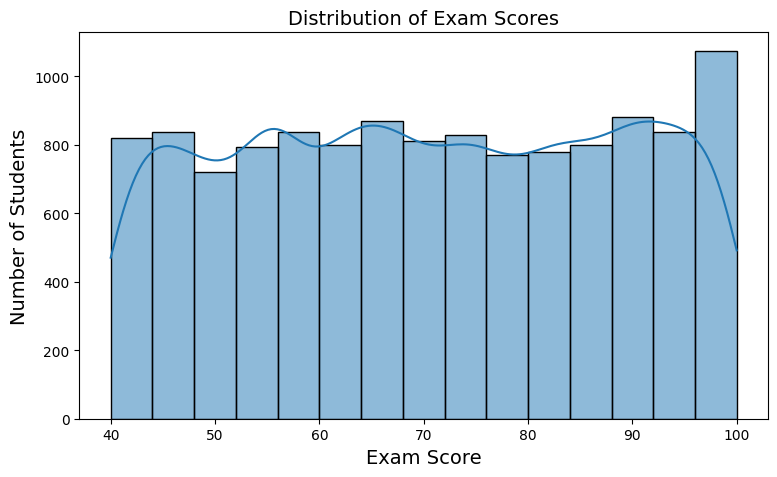

In [28]:
# plotting histogram to visulize the exam score distribution
plt.figure(figsize=(8, 5))
sns.histplot(student_data_clean["ExamScore"], bins=15, kde= True)
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")
save_fig("exam_score_distribution")
plt.show()

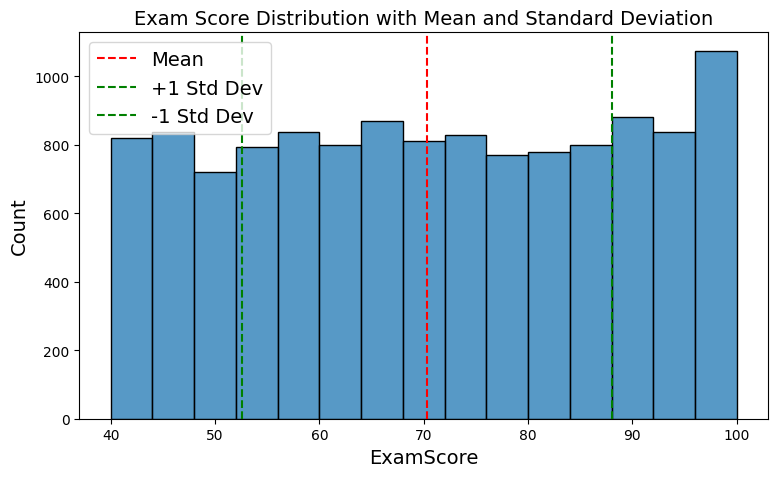

In [29]:
mean_score = student_data_clean["ExamScore"].mean()
std_score = student_data_clean["ExamScore"].std()

# exam score distribution with mean and std

plt.figure(figsize=(8, 5))
sns.histplot(student_data_clean["ExamScore"], bins=15)
plt.axvline(mean_score, color="red", linestyle="--", label="Mean")
plt.axvline(mean_score + std_score, color="green", linestyle="--", label="+1 Std Dev")
plt.axvline(mean_score - std_score, color="green", linestyle="--", label="-1 Std Dev")
plt.legend()
plt.title("Exam Score Distribution with Mean and Standard Deviation")
save_fig("exam_score_mean_std")
plt.show()

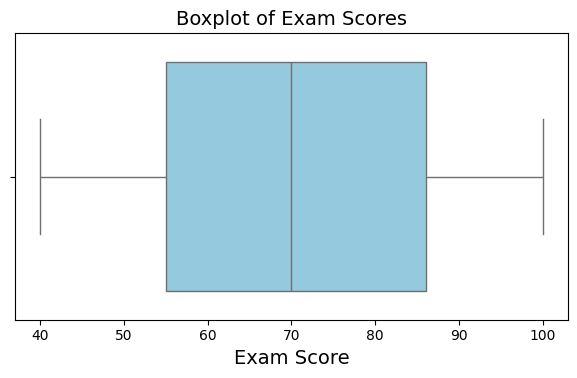

In [30]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=student_data_clean["ExamScore"], color="skyblue")
plt.xlabel("Exam Score")
plt.title("Boxplot of Exam Scores")
save_fig("exam_score_boxplot")
plt.show()

## Extra Insights and Exploratory Observations

In [31]:
gender_counts = student_data["Gender"].value_counts()

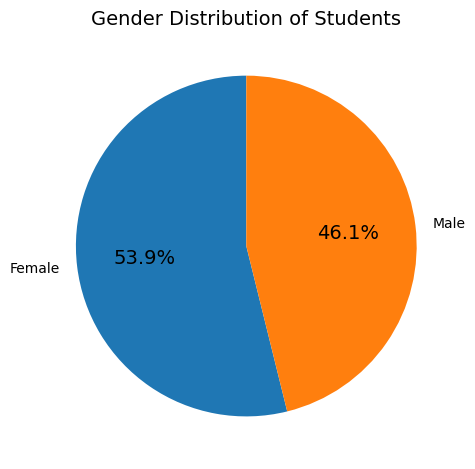

In [32]:
plt.figure(figsize=(5, 5))
plt.pie(gender_counts,labels=["Female", "Male"],autopct="%1.1f%%",startangle=90)
plt.title("Gender Distribution of Students")
save_fig("gender_distribution_pie")
plt.show()

> This shows the equal particaption of male and female students in exam not very small difference

In [33]:
gender_mean_scores = student_data.groupby("Gender")["ExamScore"].mean()

In [34]:
gender_mean_scores

Gender
0    69.990440
1    70.585021
Name: ExamScore, dtype: float64

> Almost same as from corr not a big factor as both are performing eqully

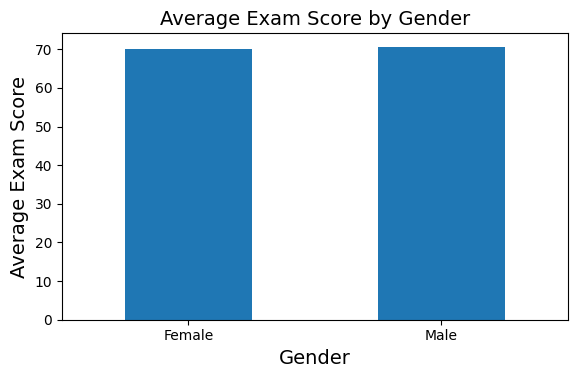

In [35]:
plt.figure(figsize=(6, 4))
gender_mean_scores.plot(kind="bar")
plt.xticks([0, 1], ["Female", "Male"], rotation=0)
plt.ylabel("Average Exam Score")
plt.title("Average Exam Score by Gender")
save_fig("exam_score_by_gender")
plt.show()

> Lets have a look over Distribution of students on behalf of different learning style

In [36]:
learning_style_counts = student_data["LearningStyle"].value_counts().sort_index()

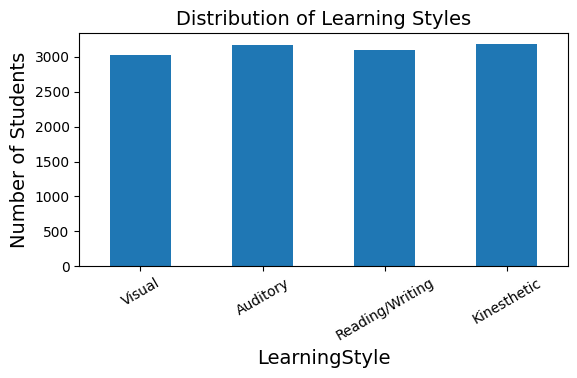

In [37]:
plt.figure(figsize=(6, 4))
learning_style_counts.plot(kind="bar")
plt.xticks(ticks=[0, 1, 2, 3],labels=["Visual", "Auditory", "Reading/Writing", "Kinesthetic"],rotation=30)
plt.ylabel("Number of Students")
plt.title("Distribution of Learning Styles")
save_fig("learning_style_distribution")
plt.show()

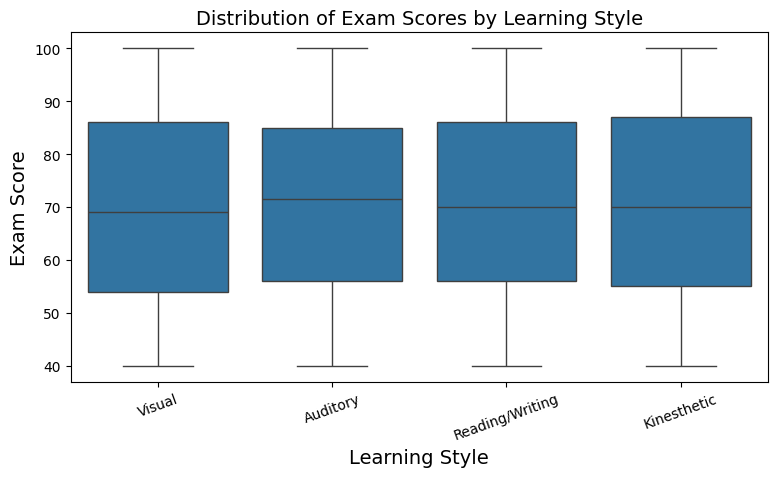

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=student_data["LearningStyle"], y=student_data["ExamScore"])
plt.xticks(ticks=[0, 1, 2, 3],labels=["Visual", "Auditory", "Reading/Writing", "Kinesthetic"],rotation=20)
plt.xlabel("Learning Style")
plt.ylabel("Exam Score")
plt.title("Distribution of Exam Scores by Learning Style")
save_fig("exam_score_by_learning_style_boxplot")
plt.show()

## Conclusion

This study analyzed student exam score distributions using descriptive statistics and exploratory visualizations. 
The results indicate a moderately difficult assessment with balanced score dispersion. 
Correlation analysis revealed that no single behavioral, psychological, or environmental factor independently determines exam performance, highlighting the multifactorial nature of academic outcomes.

---

**End**